In [3]:
# main_report.ipynb - Project 7
# Reproduces every figure and number in the report from the saved checkpoints.
# No DDPM is trained here.
import math, pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchvision import utils
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('device:', device)

timesteps  = 1000
image_size = 20
channels   = 1
n_classes  = 10

device: cuda


In [4]:
d = torch.load('mnist_custom.pt', map_location='cpu', weights_only=False)
for k, v in d.items():
    print(k, tuple(v.shape), v.dtype)

train_images (60000, 1, 20, 20) torch.float32
train_labels (60000,) torch.int64
test_images (10000, 1, 20, 20) torch.float32
test_labels (10000,) torch.int64


In [5]:
# --- tutorial cell: extract() and q_sample() are unchanged ---
import math

def extract(a, t, x_shape):
    """
    Extracts coefficients at specified timesteps, then reshapes to [batch_size, 1, 1, 1] for broadcasting purposes 
    (piecewise multiplication with the noise image)
    a: Tensor of shape (num_timesteps) (e.g. alpha_bar)
    t: Tensor of shape (batch_size) with timestep indices
    """    
    batch_size = t.shape[0]
    out = a.gather(-1, t).reshape(batch_size, *((1,) * (len(x_shape) - 1)))
    return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
timesteps = 1000
image_size = 20          # 20x20 for this dataset, the tutorial used 28
channels = 1

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, timesteps)


def cosine_beta_schedule(timesteps, s=0.008):
    """
    Cosine schedule from Nichol & Dhariwal (2021), "Improved Denoising Diffusion
    Probabilistic Models". Instead of defining beta directly, it defines the
    cumulative product alpha_bar as a squared cosine:

        alpha_bar(t) = cos((t/T + s) / (1 + s) * pi/2)^2,   normalised so alpha_bar(0) = 1

    and recovers beta from the ratio of consecutive alpha_bar values.
    The small offset s = 0.008 stops beta from being too close to 0 at t = 0.
    betas are clipped at 0.999 so the process never becomes singular.
    """
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps) / timesteps
    alphas_cumprod = torch.cos((t + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0, 0.999)


def set_schedule(name):
    """
    Reassigns the global betas / alphas / alpha_bars that q_sample and the
    sampling functions read. Done this way so q_sample and p_sample stay exactly
    as written in the tutorial instead of taking extra arguments.
    """
    global betas, alphas, alpha_bars
    if name == 'linear':
        betas = linear_beta_schedule(timesteps).to(device)
    elif name == 'cosine':
        betas = cosine_beta_schedule(timesteps).to(device)
    else:
        raise ValueError(f'unknown schedule: {name}')
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)

cuda


In [6]:
channels = 1 # for MNIST

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)


class UNet_cond(nn.Module):
    def __init__(self, ch=32, n_classes=10):
        super().__init__()
        # encoder
        self.enc1 = ConvBlock(channels, ch)
        self.enc2 = ConvBlock(ch, ch*2)
        # bottleneck
        self.bot = ConvBlock(ch*2, ch*2)
        # decoder
        self.dec2 = ConvBlock(ch*2 + ch*2, ch)
        self.dec1 = ConvBlock(ch + ch, ch)
        # final
        self.final = nn.Conv2d(ch, channels, 1)

        # timestep embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(1, ch),
            nn.ReLU(),
            nn.Linear(ch, ch)
        )

        # class embedding
        self.class_emb =  nn.Embedding(n_classes,ch)

        # projections to match channel dims
        self.to_e1 = nn.Conv2d(ch, ch, 1)
        self.to_e2 = nn.Conv2d(ch, ch*2, 1)
        self.to_b  = nn.Conv2d(ch, ch*2, 1)
        self.to_d2 = nn.Conv2d(ch, ch, 1)
        self.to_d1 = nn.Conv2d(ch, ch, 1)

        self.pool = nn.AvgPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x, t, y):        
        t = t.float().unsqueeze(-1) / timesteps
        t_emb = self.time_mlp(t).unsqueeze(-1).unsqueeze(-1)  

        y_emb = self.class_emb(y).unsqueeze(-1).unsqueeze(-1)

        cond_emb = t_emb + y_emb

        e1 = self.enc1(x) + self.to_e1(cond_emb)
        e2 = self.enc2(self.pool(e1)) + self.to_e2(cond_emb)

        b = self.bot(self.pool(e2)) + self.to_b(cond_emb)

        d2 = self.upsample(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2) + self.to_d2(cond_emb)

        d1 = self.upsample(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1) + self.to_d1(cond_emb)

        return self.final(d1)

In [7]:
models = {}
for name in ['linear', 'cosine']:
    m = UNet_cond(ch=32, n_classes=n_classes).to(device)
    m.load_state_dict(torch.load(f'ddpm_{name}.pth', map_location=device))
    m.eval()
    models[name] = m
    print(f'loaded ddpm_{name}.pth')
print('params:', sum(p.numel() for p in models['linear'].parameters()))

loaded ddpm_linear.pth
loaded ddpm_cosine.pth
params: 221569


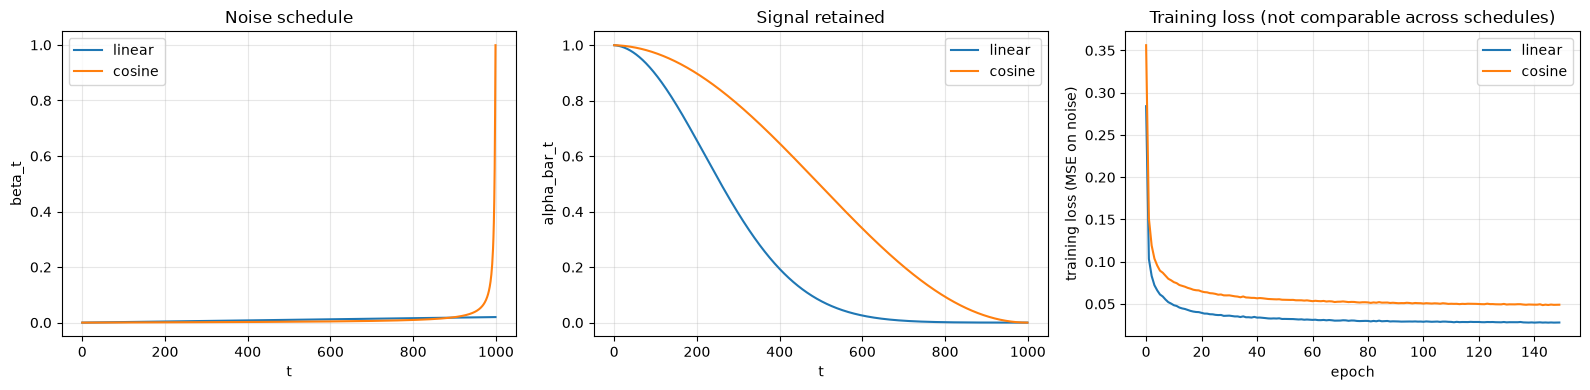

linear  alpha_bar t=500: 0.0778   first t<0.5:  259   first t<0.01:  673
cosine  alpha_bar t=500: 0.4923   first t<0.5:  496   first t<0.01:  935

final training loss  linear 0.02804  cosine 0.04910
training time (s)    linear 1257.4  cosine 2245.5
NOTE: both schedules do identical work per step, so the measured time difference
      reflects the shared GPU, not a property of the schedule.


In [8]:
betas_lin = linear_beta_schedule(timesteps); abar_lin = torch.cumprod(1 - betas_lin, 0)
betas_cos = cosine_beta_schedule(timesteps); abar_cos = torch.cumprod(1 - betas_cos, 0)

with open('losses_linear.pkl', 'rb') as f: L = pickle.load(f)
with open('losses_cosine.pkl', 'rb') as f: C = pickle.load(f)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(betas_lin.numpy(), label='linear'); ax[0].plot(betas_cos.numpy(), label='cosine')
ax[0].set_xlabel('t'); ax[0].set_ylabel('beta_t'); ax[0].set_title('Noise schedule')
ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(abar_lin.numpy(), label='linear'); ax[1].plot(abar_cos.numpy(), label='cosine')
ax[1].set_xlabel('t'); ax[1].set_ylabel('alpha_bar_t'); ax[1].set_title('Signal retained')
ax[1].legend(); ax[1].grid(alpha=.3)

ax[2].plot(L['losses'], label='linear'); ax[2].plot(C['losses'], label='cosine')
ax[2].set_xlabel('epoch'); ax[2].set_ylabel('training loss (MSE on noise)')
ax[2].set_title('Training loss (not comparable across schedules)')
ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.savefig('report_fig1.png', dpi=150, bbox_inches='tight'); plt.show()

for nm, ab in [('linear', abar_lin), ('cosine', abar_cos)]:
    print(f'{nm:7s} alpha_bar t=500: {ab[500]:.4f}   first t<0.5: {(ab<0.5).nonzero()[0].item():4d}   '
          f'first t<0.01: {(ab<0.01).nonzero()[0].item():4d}')
print(f"\nfinal training loss  linear {L['losses'][-1]:.5f}  cosine {C['losses'][-1]:.5f}")
print(f"training time (s)    linear {L['train_time']:.1f}  cosine {C['train_time']:.1f}")
print('NOTE: both schedules do identical work per step, so the measured time difference')
print('      reflects the shared GPU, not a property of the schedule.')

In [9]:
@torch.no_grad()
def p_sample_cDDPM(model, x_t, t_index, y):
    """
    Single reverse step
    t_index: scalar int (0..T-1) (all elements in batch have same t)
    """
    t = torch.full((x_t.shape[0],), t_index, device=x_t.device, dtype=torch.long)
    beta = extract(betas, t, x_t.shape)
    alpha = extract(alphas, t, x_t.shape)
    alpha_bar = extract(alpha_bars, t, x_t.shape)
    sigma = torch.sqrt(beta)
    
    pred_noise = model(x_t, t, y)

    if t_index == 0:
        z = 0
    else:
        z = torch.randn_like(x_t)
    
    x_tm1 = 1.0 / alpha.sqrt() * (x_t - beta / ( (1 - alpha_bar).sqrt() ) * pred_noise) + sigma*z
    
    return x_tm1


@torch.no_grad()

def p_sample_loop_cDDPM(model, y, seed=1337):
    model.eval()
    torch.manual_seed(seed)
    n_samples = y.shape[0]
    x = torch.randn(n_samples, channels, image_size, image_size).to(device)  # x_T ~ N(0,I)
    pbar = tqdm(reversed(range(0, timesteps)), desc='Sampling loop', total=timesteps, colour='BLUE')
    for t in pbar:
        x = p_sample_cDDPM(model, x, t , y)
    return x.clamp(-1,1)

In [10]:
@torch.no_grad()
def p_sample_loop_strided(model, y, n_steps, seed=1337):
    """
    DDPM sampling using only a subset of the 1000 training timesteps.

    The model was trained on all 1000 steps; at generation time we walk a shorter
    evenly-spaced subsequence of them. The model is still called with the ORIGINAL
    timestep index, because that is what its time embedding was trained on.

    Unlike the tutorial's p_sample_cDDPM, this uses the posterior form of the
    reverse step: the predicted noise is first converted into a predicted clean
    image x0, which is clamped to [-1, 1] before taking the step. That clamp is
    essential here. With large jumps the coefficient 1/sqrt(alpha) becomes huge
    (over 3000x for the cosine schedule at 10 steps, because its alpha_bar decays
    to ~1e-9 at t=999), so any error in the predicted noise is amplified until the
    image saturates. Clamping x0 bounds that amplification.
    Both forms are algebraically the same reverse step when the jumps are small.

    This function is not part of Tutorial 9.3. It is needed because the tutorial's
    sampling loop always runs the full 1000 steps, so it cannot test a hypothesis
    about using fewer steps.
    """
    model.eval()
    torch.manual_seed(seed)
    x = torch.randn(y.shape[0], channels, image_size, image_size).to(device)

    seq = torch.linspace(0, timesteps - 1, n_steps).long().flip(0).tolist()
    one = torch.tensor(1.0, device=device)

    for i, t_cur in enumerate(seq):
        t_batch = torch.full((x.shape[0],), t_cur, device=device, dtype=torch.long)

        ab_t    = alpha_bars[t_cur]
        ab_prev = alpha_bars[seq[i + 1]] if i + 1 < len(seq) else one
        last    = (i + 1 == len(seq))

        pred_noise = model(x, t_batch, y)

        # predicted clean image, clamped to the valid pixel range
        x0 = (x - (1 - ab_t).sqrt() * pred_noise) / ab_t.sqrt()
        x0 = x0.clamp(-1, 1)

        if last:
            x = x0
        else:
            # posterior q(x_prev | x_t, x0) of the respaced chain
            alpha_i    = ab_t / ab_prev
            beta_tilde = (1 - ab_prev) / (1 - ab_t) * (1 - alpha_i)
            mean = ((ab_prev.sqrt() * (1 - alpha_i) / (1 - ab_t)) * x0
                    + (alpha_i.sqrt() * (1 - ab_prev) / (1 - ab_t)) * x)
            x = mean + beta_tilde.sqrt() * torch.randn_like(x)

    return x.clamp(-1, 1)

Sampling loop: 100%|██████████| 1000/1000 [00:10<00:00, 95.74it/s]


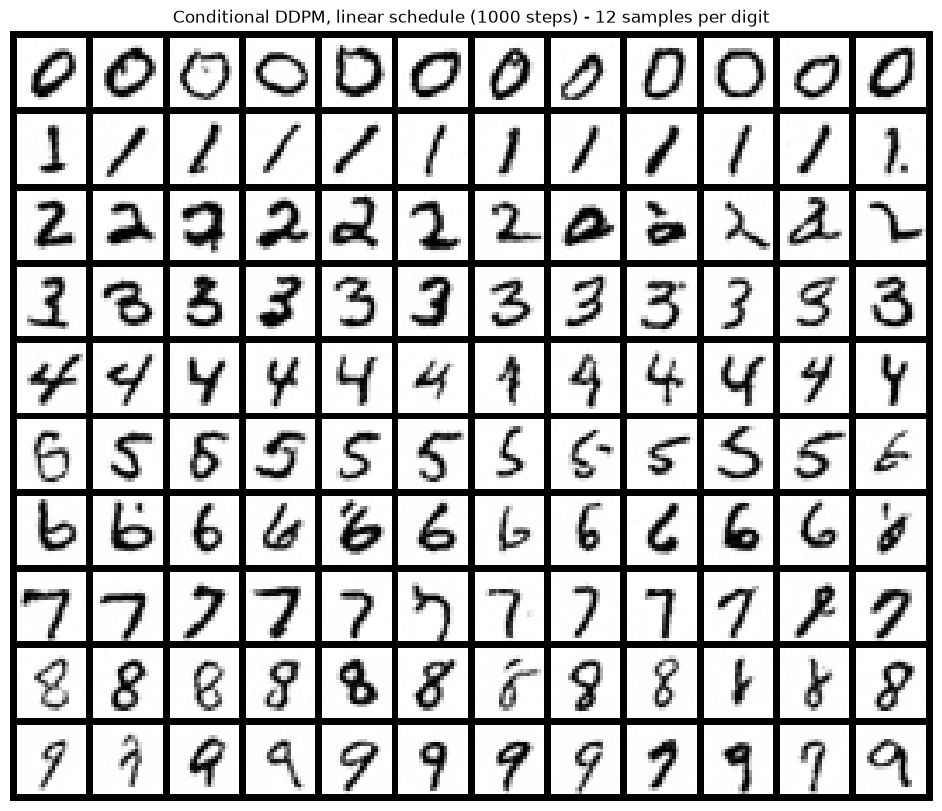

Sampling loop: 100%|██████████| 1000/1000 [00:10<00:00, 98.01it/s]


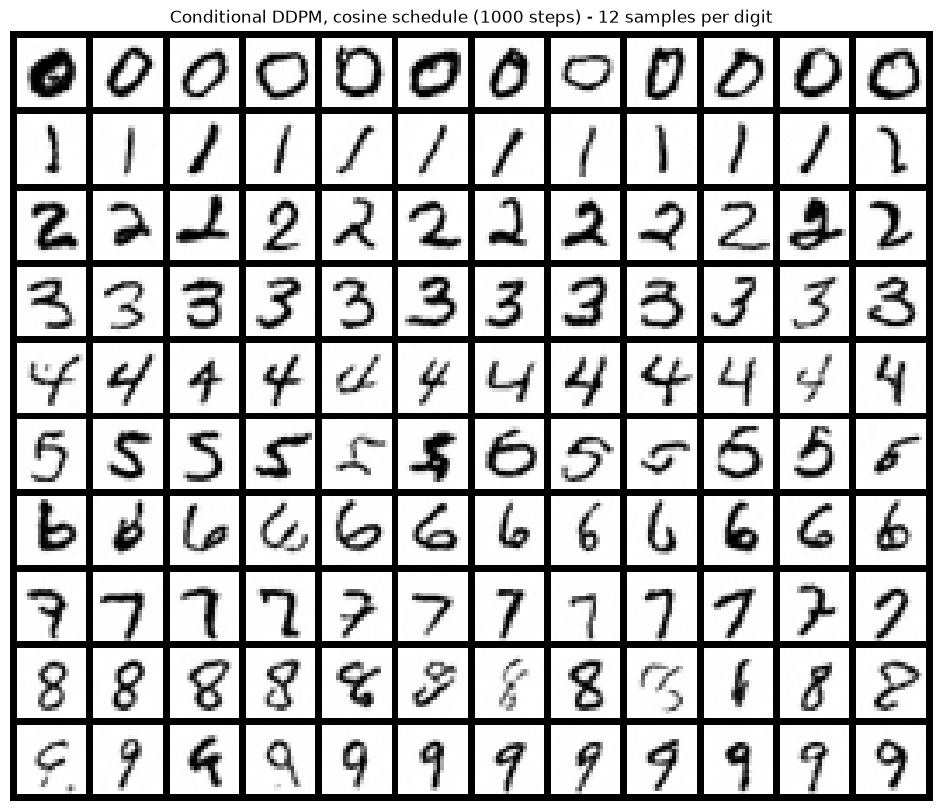

In [11]:
sample_per_class = 12
labels = torch.arange(0,10).unsqueeze(1).repeat(1,sample_per_class).view(-1).to(device)

for name, model in models.items():
    set_schedule(name)
    s = (p_sample_loop_cDDPM(model, labels) + 1.0) / 2.0
    plt.figure(figsize=(12,10)); plt.axis('off')
    plt.imshow(utils.make_grid(s, nrow=sample_per_class).permute(1,2,0).cpu())
    plt.title(f'Conditional DDPM, {name} schedule (1000 steps) - 12 samples per digit')
    plt.savefig(f'report_grid_{name}.png', dpi=150, bbox_inches='tight'); plt.show()